In [ ]:
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt

# MyAnimeList Data Exercise

In this file, I will practice my data processing skills.

The link for the dataset: [MyAnimeList](https://www.kaggle.com/datasets/andreuvallhernndez/myanimelist)

### In order to work, type:
     pip install ipykernel jupyter 
in the Terminal with active environtmet to install dependencies.

### Problem 1: Exploring data.
    Here I will download dataset resources and get to know with the topic. I will explore and analyse it. Also will assign the datasets to variables.

In [107]:
anime_dataset = pd.read_csv("anime.csv")


list(anime_dataset.columns)
anime_dataset["type"].head() # show the first 5 values of the named column in current dataset.
type(anime_dataset["type"].iloc[0]) # show the data type of the value in the first row of the named column in current dataset.
anime_dataset.dtypes # show the data types of each column in the current dataset.


anime_dataset_backup = anime_dataset.copy()


In [109]:
manga_dataset = pd.read_csv("manga.csv")


list(manga_dataset.columns)
manga_dataset["genres"].head()
type(manga_dataset["genres"].iloc[0])
manga_dataset.dtypes

manga_dataset_backup = manga_dataset.copy()

#### Conclusion from Problem 1:
    There are dates,times that are in string format. 
    There are lists that are assign as strings(columns with lists '.iloc[0] also shows 'str'. ').
    The columns are in snake_case.

### Problem 2. Shape and types.
Here I will find out the structures, try to cach the problems and make the first corrections

In [110]:
anime_dataset.shape # show the number of rows and columns in the current dataset. // 24985 rows and 39 cols.
manga_dataset.shape # show the number of rows and columns in the current dataset. // 64833 rows and 30 cols.

# anime_dataset.columns = anime_dataset.columns.str.lower().str.replace(" ", "_") # rename the columns for Python in snake_case format.

(64833, 30)

#### Conclusion from Problem 2:
TODO:
    anime_dataset 'wrong' -> 'correct':
    
    NUMERICAL DATA:
    broadcast_time            str -> to_datetime

    DATE DATA:
    start_date                str -> date
    end_date                  str -> date
    created_at                str -> date
    updated_at                str -> date
    real_start_date           str -> date
    real_end_date             str -> date
    
    MESSY DATA:
    genres                    str -> lists
    themes                    str -> lists
    demographics              str -> lists
    studios                   str -> lists
    producers                 str -> lists
    licensors                 str -> lists
    title_synonyms            str -> lists

TODO:
    manga_dataset 'wrong' -> 'correct':

    DATE DATA:
    start_date                str -> date
    end_date                  str -> date
    created_at_before         str -> date
    updated_at                str -> date
    real_start_date           str -> date
    real_end_date             str -> date

    
    MESSY DATA:
    genres                    str -> lists
    themes                    str -> lists
    demographics              str -> lists
    authors                   str -> lists
    serializations            str -> lists
    title_synonyms            str -> lists







### Problem 3. Data validation
    Here I will find missing values.
    unique elements.
    duplicated rows.
    red flags.
    unnecessary cols.


In [111]:
anime_dataset.isnull().sum() # show the number of missing values in each column of the current dataset.
anime_dataset.isnull().sum() / len(anime_dataset) * 100 # show the percentage of missing values in each column of the current dataset.

anime_dataset["status"].unique() # show the unique values in the named column of the current dataset.

anime_dataset.duplicated().sum() # show the number of duplicate rows in the current dataset.

anime_dataset["score"].describe() # show the summary statistics of the named column in the current dataset.

count    16050.000000
mean         6.418470
std          0.899305
min          1.850000
25%          5.800000
50%          6.420000
75%          7.070000
max          9.100000
Name: score, dtype: float64

In [112]:
manga_dataset.isnull().sum()
manga_dataset.isnull().sum() / len(manga_dataset) * 100

manga_dataset["status"].unique()

manga_dataset.duplicated().sum()

manga_dataset["score"].describe()

count    24636.000000
mean         6.945179
std          0.520170
min          2.440000
25%          6.620000
50%          6.910000
75%          7.250000
max          9.470000
Name: score, dtype: float64

#### Conclusion from Problem 3:
##### The following rows are mostly 'null' and are considerate for deletion.:
    anime: 'broadcast_day'; 'broadcast_time'; 'background'.


##### The following cols are mostly useless and are considerate for deletion:
    anime: 'main_picture';.
    manga: 'main_picture'; 'background'.   


##### Duplicats:
    anime - none.
    manga - none.

### Problem 4. Missing values
    Here I will:
        - Drop rows with missing values.
        - Drop the useless cols in my opinion.

In [ ]:
list(anime_dataset.columns)
anime_dataset = anime_dataset.dropna(subset=[
        "broadcast_day","broadcast_time","background",
    ]) # drop the rows with missing values in the named column of the current dataset.
anime_dataset.isnull().sum() / len(anime_dataset) * 100 # check percentage for ensuring that the missing values have been removed from the current dataset.

anime_dataset = anime_dataset.drop(columns=["main_picture"]) # drop the named column from the current dataset.
list(anime_dataset.columns) # validate that the named column has been removed from the current dataset.

In [ ]:
list(manga_dataset.columns)

cols_to_drop = ["main_picture", "background",]
existing_cols = [col for col in cols_to_drop if col in manga_dataset.columns]

manga_dataset = manga_dataset.drop(columns=existing_cols)
list(manga_dataset.columns) # validate that the named column has been removed from the current dataset.

#### Conclusion from Problem 4:
    - I removed null rows and also removed the unnecesary cols.

### Problem 5. Dates / Time / Lists
    Here I will fix date, time, list formats.

In [ ]:
anime_date_cols = ["start_date", "end_date", "created_at", "updated_at", "real_start_date", "real_end_date"]
anime_dataset[anime_date_cols].dtypes

for col in anime_date_cols:
    anime_dataset[col] = pd.to_datetime(anime_dataset[col],  errors='coerce') # converting. 'coerce' includes invalid ones.
anime_dataset[anime_date_cols].dtypes
anime_dataset[anime_date_cols]
anime_dataset[anime_date_cols].isnull().sum() # checks if there are NaT values - problem if they are many


anime_dataset["broadcast_time"]
anime_dataset["broadcast_time"].dtype
anime_dataset["broadcast_time"] = anime_dataset["broadcast_time"].astype("object").str.strip() # convert to string and remove leading/trailing whitespace characters.
anime_dataset["broadcast_time"].dtype


anime_dataset["broadcast_time"] = pd.to_datetime(
    anime_dataset["broadcast_time"], 
    format="%H:%M:%S",
    errors="coerce"
)

anime_dataset["broadcast_time"]

anime_dataset_lists = ["genres", "themes", "demographics", "studios", "producers", "licensors", "title_synonyms"]
anime_dataset[anime_dataset_lists].dtypes


def safe_parse_list(x):
    if pd.isna(x):
        return []  # NaN - empty list

    if isinstance(x, list):
        return x

    if isinstance(x, str):
        x = x.strip()
        if not x:
            return []

        if x.startswith('[') and x.endswith(']'):
            try:
                result = ast.literal_eval(x)
                if isinstance(result, list):
                    return [str(i).strip() for i in result]
            except Exception:
                pass  # not returning [], but None
        return None  # if not a valid list string

    return None

anime_list_cols_safe = [
    'genres', 'themes', 'demographics',
    'studios', 'licensors', 'title_synonyms'
] # "producers" is not a valid data type for parsing as a list, so it is excluded from the list of columns to be parsed.

for col in anime_list_cols_safe:
    try:
        anime_dataset[col] = anime_dataset[col].apply(safe_parse_list)
    except Exception as e:
        print(f"Error parsing column '{col}': {e}")

anime_dataset[anime_list_cols_safe].dtypes
anime_dataset[anime_list_cols_safe].head()


manga_list_cols = [
    "genres", "themes", "demographics", "authors", "serializations", "title_synonyms"
]

for col in manga_list_cols:
    try:
        manga_dataset[col] = manga_dataset[col].apply(safe_parse_list)
    except Exception as e:
        print(f"Error parsing column '{col}': {e}")

manga_dataset[manga_list_cols].dtypes
manga_dataset[manga_list_cols].head()



In [ ]:
manga_data_cols = ["start_date", "end_date", "created_at_before", "updated_at", "real_start_date", "real_end_date"]
manga_dataset[manga_data_cols].dtypes

for col in manga_data_cols:
    manga_dataset[col] = pd.to_datetime(manga_dataset[col], errors='coerce')
manga_dataset[manga_data_cols].dtypes
manga_dataset[manga_data_cols]



#### Conclusion from Problem 5:

##### The following are fixed:
    dates from string to datetime;
    time from string to datetime;
    string of lists to

#### "producers" is not a valid data type for parsing as a list, so it is excluded from the list of columns to be parsed.
    

### Problem 6. Anime vs Manga
    Here I will compare the two datasets - only the 'score' cols.

In [ ]:
# Mean, median, min, max
anime_dataset["score"].describe()

In [ ]:
manga_dataset["score"].describe()

#### Conclusion from Problem 5:
    Made a simple 'score' columns comparison.

In [1]:
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In this section I will compare 'anime' and 'manga' datasets using plots.
On the first line I will do simple test Histogram

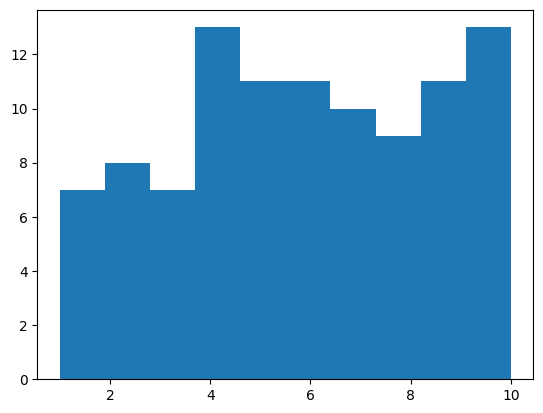

In [20]:
import numpy as np
import matplotlib.pyplot as plt
test_random_values = np.random.randint(1, 11, 100)
plt.hist(test_random_values)
plt.show()

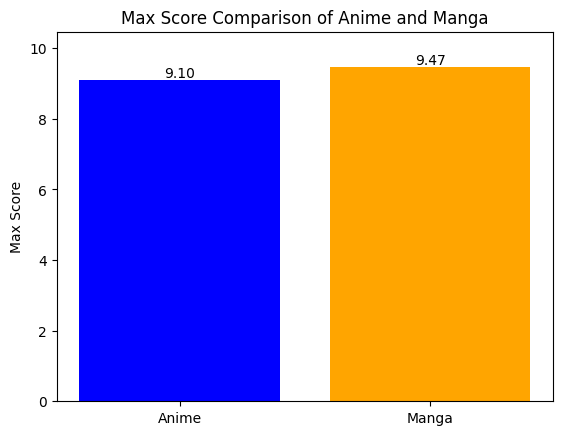

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

anime_dataset = pd.read_csv("anime.csv")
manga_dataset = pd.read_csv("manga.csv")


# Get the highest by score anime and manga
anime_max_score = anime_dataset["score"].max()
manga_max_score = manga_dataset["score"].max()


labels = ["Anime", "Manga"]
values = [anime_max_score, manga_max_score]

bars = plt.bar(labels, values, color=['blue', 'orange'])

# # legend
# bars[0].set_label("Anime")
# bars[1].set_label("Manga")
# plt.legend()

# Show the values on top of the bars
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, y, 
             f"{y:.2f}",
            ha='center', 
            va='bottom'
        )
    

# set y-axis limit to be slightly above the max value for better visualization.
plt.ylim(0, max(values) + 1)


plt.ylabel("Max Score")
plt.title("Max Score Comparison of Anime and Manga")
plt.show()

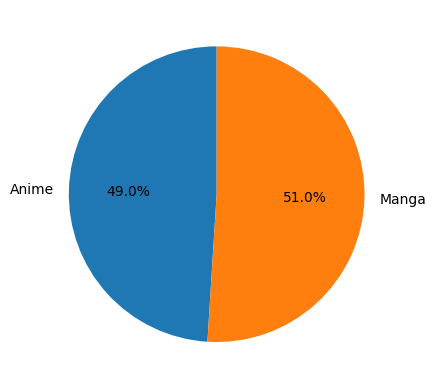

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

anime_dataset = pd.read_csv("anime.csv")
manga_dataset = pd.read_csv("manga.csv")


# Get the highest by score anime and manga
anime_max_score = anime_dataset["score"].max()
manga_max_score = manga_dataset["score"].max()

sizes = [anime_max_score, manga_max_score]
plt.pie(
    sizes, 
    labels=["Anime", "Manga"],
    autopct='%1.1f%%',
    startangle=90,
    )

# Make the plot circular
plt.gca().set_aspect('equal')